# Stage 4 hands-on — roof planes: per-roof tilt & aspect (RANSAC)

This notebook explores pipeline **stage 4**: turn each building **footprint** + the **DSM**
(from `01_footprints_and_dsm`) into a per-roof **tilt** and **aspect** — how steeply a roof
pitches, and which compass direction it faces. Tilt and aspect are what stage 6 (PVWatts) needs
to price a roof's solar yield correctly; get them wrong and the error rides straight through to
kWh and CO2.

**Why this is the weakest link (risks §14.4).** Every earlier stage (footprints, DSM, `r.sun`
shading) is built on well-established public data and a locked engine. This stage instead **fits
a plane to noisy points** — HVAC units, parapets, chimneys, and multi-facet roofs all sit in the
same DSM clip as the roof surface itself, with no ground truth to check against for an arbitrary
US city. So this notebook does not just report tilt/aspect — it reports **how much to trust each
fit**, via the RANSAC inlier ratio and the pixel count behind it.

**Phase 1 vs Phase 2.** The baseline here is **single-plane RANSAC**: one robust-fit plane per
footprint. It is honest, fast, and — as this notebook will show — a *rough* approximation for
non-trivial roofs. Phase 2 replaces it with an ML route (obstruction segmentation + multi-plane
fitting); this notebook's uncertainty numbers are the reason why.

Same tiny, self-contained AOI as `01`/`02` (a ~400 m slice of Glover Park, buffered 100 m in a
metric CRS) so every fetch and fit stays fast and inspectable.

## The plan

1. Fetch the tiny DSM (condensed from `01`) + OSM footprints, same recipe as `01`/`02`.
2. Define the RANSAC roof-plane method: clip DSM to one footprint → point cloud → fit a plane →
   tilt / aspect / inlier ratio. Sanity-check the aspect sign convention on a synthetic roof.
3. Look at **two example roofs** in 3D — one near-flat, one of the more-tilted ones — points
   coloured inlier vs. outlier, with the fitted plane surface.
4. Run it across **every footprint** in the AOI; assemble a per-roof table.
5. Look at the distributions: tilt, aspect (non-flat roofs only), a map, and — the uncertainty
   picture — the inlier-ratio distribution.
6. State the honest findings, including the multi-plane gap this baseline doesn't handle.

In [1]:
import tempfile
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import osmnx as ox
import planetary_computer as pc
import pyproj
import pystac_client
import rasterio
import rasterio.mask
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers the 3D projection
from rasterio.crs import CRS
from rasterio.merge import merge
from rasterio.transform import from_origin
from rasterio.warp import Resampling, reproject
from shapely.geometry import Polygon, box, mapping
from shapely.ops import transform as shp_transform
from sklearn.linear_model import RANSACRegressor

warnings.filterwarnings("ignore")  # keep the notebook output clean for reading

PC_STAC = "https://planetarycomputer.microsoft.com/api/stac/v1"
WORKING_CRS = "EPSG:6347"  # NAD83(2011) / UTM 18N -- metric, covers DC

# Same tiny AOI as 01/02, buffered 100 m in the metric CRS (never in degrees -- trap 2, see 01).
TINY_AOI = (-77.0770, 38.9182, -77.0730, 38.9218)
BUFFER_M = 100.0

core = box(*TINY_AOI)
to_metric = pyproj.Transformer.from_crs("EPSG:4326", WORKING_CRS, always_xy=True).transform
to_lonlat = pyproj.Transformer.from_crs(WORKING_CRS, "EPSG:4326", always_xy=True).transform
core_metric = shp_transform(to_metric, core)
buffered_metric = core_metric.buffer(BUFFER_M)
buffered = shp_transform(to_lonlat, buffered_metric)

# --- shared 2 m target grid over the buffered AOI (same recipe as 01/02) ---
dst_crs = CRS.from_string(WORKING_CRS)
minx, miny, maxx, maxy = buffered_metric.bounds
RES = 2.0
width = int(np.ceil((maxx - minx) / RES))
height = int(np.ceil((maxy - miny) / RES))
target_transform = from_origin(minx, maxy, RES, RES)
target_shape = (height, width)
extent = (minx, maxx, miny, maxy)  # matplotlib imshow extent, in metres


def fetch_dsm_to_grid(collection: str, aoi_lonlat: Polygon) -> tuple[np.ndarray, float, int]:
    """Fetch a 3DEP collection from Planetary Computer and reproject onto the shared 2 m grid.

    Condensed from 01_footprints_and_dsm's `fetch_to_grid` -- see that notebook for the full
    walkthrough of the windowed read and the compound-CRS gotcha. Returns (array, nodata, n_items).
    """
    cat = pystac_client.Client.open(PC_STAC, modifier=pc.sign_inplace)
    items = list(cat.search(collections=[collection], intersects=mapping(aoi_lonlat)).items())
    srcs = [rasterio.open(it.assets["data"].href) for it in items]
    try:
        nodata = srcs[0].nodata
        hcrs = pyproj.CRS.from_wkt(srcs[0].crs.to_wkt()).sub_crs_list[0]  # drop vertical (NAVD88)
        src_crs = CRS.from_epsg(hcrs.to_epsg())
        to_src = pyproj.Transformer.from_crs("EPSG:4326", hcrs, always_xy=True).transform
        aoi_src = shp_transform(to_src, aoi_lonlat)
        mosaic, mosaic_t = merge(srcs, bounds=aoi_src.bounds)  # windowed read, not whole tiles
    finally:
        for s in srcs:
            s.close()

    dst = np.full(target_shape, nodata, dtype=mosaic.dtype)
    reproject(
        mosaic[0], dst,
        src_transform=mosaic_t, src_crs=src_crs,
        dst_transform=target_transform, dst_crs=dst_crs,
        src_nodata=nodata, dst_nodata=nodata, resampling=Resampling.bilinear,
    )
    return dst, nodata, len(items)


dsm, dsm_nodata, n_dsm = fetch_dsm_to_grid("3dep-lidar-dsm", buffered)
print(f"DSM: grid {dsm.shape} @ {RES:.0f} m, mosaicked from {n_dsm} STAC item(s)")

# Write the DSM to a tempfile GeoTIFF -- rasterio.mask needs an on-disk/open dataset to clip
# against per footprint. Scratch only: never written into the repo tree.
workdir = tempfile.mkdtemp(prefix="roofplanes_")
dsm_path = Path(workdir) / "dsm.tif"
profile = {
    "driver": "GTiff", "dtype": dsm.dtype, "count": 1, "nodata": dsm_nodata,
    "width": target_shape[1], "height": target_shape[0],
    "crs": dst_crs, "transform": target_transform,
}
with rasterio.open(dsm_path, "w", **profile) as dst:
    dst.write(dsm, 1)

osm = ox.features_from_polygon(buffered, {"building": True})
footprints = osm[osm.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].reset_index(drop=True)
footprints_m = footprints.to_crs(WORKING_CRS)
print(f"{len(footprints_m)} building footprints in the buffered tiny AOI")
print(f"DSM scratch (tempfile, not repo): {dsm_path}")

DSM: grid (304, 278) @ 2 m, mosaicked from 3 STAC item(s)


1001 building footprints in the buffered tiny AOI
DSM scratch (tempfile, not repo): /var/folders/5n/v5lcr1s102s71gw8q1g0jh6h0000gn/T/roofplanes_d3bl99et/dsm.tif


## Footprint → roof point cloud → plane → tilt/aspect

For one footprint: clip the DSM to its polygon and keep the valid pixels as a small point cloud
`(x, y, z)` — easting, northing, surface elevation. That cloud is **not** a clean roof: at 2 m
resolution it also carries HVAC units, parapets, and (for the smallest buildings) very few
pixels at all.

Fit a plane `z = a*x + b*y + c` with **RANSAC** — it fits robustly to the majority "inlier"
surface and *ignores* outlier clutter, which is exactly the property we want here. From the
fitted coefficients:

- **tilt** = `atan(hypot(a, b))` — how steeply the plane pitches, regardless of direction.
- **aspect** = `atan2(-a, -b) % 360` — the compass azimuth the roof *faces* (0=N, 90=E, 180=S,
  270=W); the sign flip is because `a`, `b` are the *uphill* gradient, and a roof faces
  *downhill*.
- **inlier ratio** = the fraction of points RANSAC accepted as belonging to the plane — our
  fit-quality / uncertainty proxy. A single, clean, single-pitch roof should score high; a
  cluttered or multi-facet one scores low **and that low score is itself the signal to report**,
  not a bug to fix quietly.

In [2]:
MIN_PX = 6  # below this many DSM pixels, don't trust a plane fit at all


def roof_points(
    geom: Polygon, dsm_path: Path
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """Clip the DSM to `geom` and return the roof's raw point cloud.

    Returns (X, z): X is an (n, 2) array of (easting, northing), z is an (n,) array of surface
    elevations. This is the unfiltered 2 m DSM clip -- clutter (HVAC, parapets, overhanging
    trees) included, exactly as the RANSAC fit below will see it.
    """
    with rasterio.open(dsm_path) as src:
        out_image, out_transform = rasterio.mask.mask(src, [mapping(geom)], crop=True)
        nodata = src.nodata
    band = out_image[0]
    rows, cols = np.where(band != nodata)
    if rows.size == 0:
        return np.empty((0, 2)), np.empty((0,))
    xs, ys = rasterio.transform.xy(out_transform, rows, cols)
    X = np.column_stack([xs, ys]).astype(np.float64)
    z = band[rows, cols].astype(np.float64)
    return X, z


def fit_roof_plane(
    X: npt.NDArray[np.float64], z: npt.NDArray[np.float64]
) -> dict[str, object]:
    """Fit one RANSAC plane z = a*x + b*y + c to a roof's point cloud.

    Returns a dict: tilt_deg, aspect_deg, inlier_ratio, n_px, coef (a, b, c), inlier_mask,
    low_confidence. `inlier_ratio` and `n_px` are the uncertainty proxies this stage leans on --
    a low ratio or a handful of pixels means "treat this tilt/aspect as low-confidence", not
    "the plane must be right." Roofs under MIN_PX pixels are flagged outright (no fit attempted).
    """
    n_px = int(len(z))
    if n_px < MIN_PX:
        return {
            "tilt_deg": np.nan, "aspect_deg": np.nan, "inlier_ratio": np.nan,
            "n_px": n_px, "coef": (np.nan, np.nan, np.nan),
            "inlier_mask": np.zeros(n_px, dtype=bool), "low_confidence": True,
        }
    ransac = RANSACRegressor(residual_threshold=0.5, random_state=0)
    ransac.fit(X, z)
    a, b = (float(v) for v in ransac.estimator_.coef_)
    c = float(ransac.estimator_.intercept_)
    inlier_mask = ransac.inlier_mask_
    tilt_deg = float(np.degrees(np.arctan(np.hypot(a, b))))
    aspect_deg = float(np.degrees(np.arctan2(-a, -b)) % 360.0)
    inlier_ratio = float(inlier_mask.mean())
    return {
        "tilt_deg": tilt_deg, "aspect_deg": aspect_deg, "inlier_ratio": inlier_ratio,
        "n_px": n_px, "coef": (a, b, c), "inlier_mask": inlier_mask,
        "low_confidence": bool(inlier_ratio < 0.5 or n_px < 20),
    }


# Sanity-check the sign convention: a synthetic roof with NO east-west slope and elevation
# rising to the north (ridge at north, eave at south) faces due south -- aspect should be ~180.
_rows, _cols = np.meshgrid(np.arange(20.0), np.arange(20.0), indexing="ij")
_true_pitch_deg = 20.0
_test_z = np.tan(np.radians(_true_pitch_deg)) * _rows  # z grows with northing only
_test_X = np.column_stack([_cols.ravel(), _rows.ravel()])
_check = fit_roof_plane(_test_X, _test_z.ravel())
print(
    f"sign-convention check (synthetic {_true_pitch_deg:.0f} deg south-facing roof): "
    f"fitted tilt {_check['tilt_deg']:.1f} deg, aspect {_check['aspect_deg']:.0f} deg "
    "(expect ~180 = south)"
)
assert abs(_check["aspect_deg"] - 180.0) < 1.0, "aspect sign convention looks wrong"
assert abs(_check["tilt_deg"] - _true_pitch_deg) < 1.0, "tilt looks wrong"
print("aspect/tilt sign convention verified on synthetic data.")

sign-convention check (synthetic 20 deg south-facing roof): fitted tilt 20.0 deg, aspect 180 deg (expect ~180 = south)
aspect/tilt sign convention verified on synthetic data.


## Two example roofs — before trusting the whole AOI

Before running this on every footprint, look at two individual fits in 3D: the DSM points,
coloured **inlier (green)** vs. **outlier (red)**, with the fitted plane as a translucent
surface. Picking the examples requires a fit for every footprint anyway, so the loop below
computes all of them once and both this cell and the AOI-wide analysis further down reuse the
same `fits` list — nothing here is recomputed twice.

Example A (near-flat): idx 228, tilt 0.1 deg, n_px 346, inlier 0.60
Example B (more-tilted): idx 928, tilt 57.1 deg, n_px 33, inlier 0.30


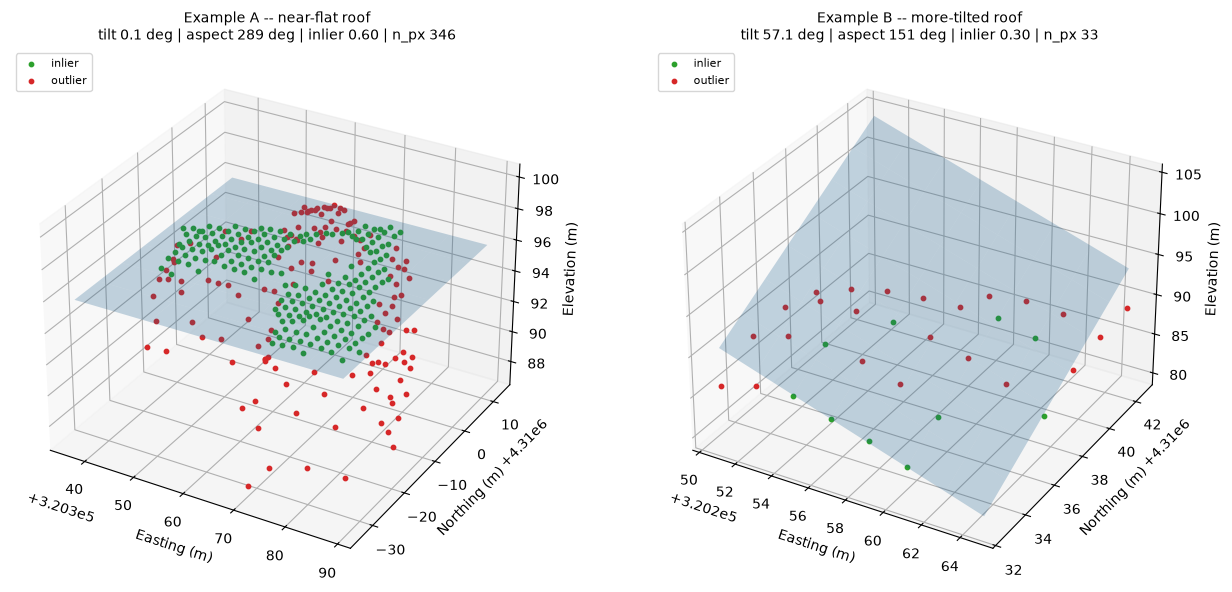

In [3]:
fits: list[dict[str, object]] = []
for geom in footprints_m.geometry:
    X, z = roof_points(geom, dsm_path)
    fits.append(fit_roof_plane(X, z))

tilts = np.array([f["tilt_deg"] for f in fits], dtype=float)
inlier_ratios = np.array([f["inlier_ratio"] for f in fits], dtype=float)
n_pxs = np.array([f["n_px"] for f in fits], dtype=float)
valid = ~np.isnan(tilts)

# Example A: a near-flat roof with enough pixels to be a fair 3D example (largest such roof).
flat_candidates = np.where(valid & (tilts < 5.0) & (n_pxs > 50))[0]
flat_idx = (
    int(flat_candidates[np.argmax(n_pxs[flat_candidates])])
    if len(flat_candidates)
    else int(np.nanargmin(tilts))
)

# Example B: one of the more-tilted roofs, still with enough pixels for a fair fit.
tilted_candidates = np.where(valid & (n_pxs > 30))[0]
tilted_idx = int(tilted_candidates[np.argmax(tilts[tilted_candidates])])

print(f"Example A (near-flat): idx {flat_idx}, tilt {tilts[flat_idx]:.1f} deg, "
      f"n_px {int(n_pxs[flat_idx])}, inlier {inlier_ratios[flat_idx]:.2f}")
print(f"Example B (more-tilted): idx {tilted_idx}, tilt {tilts[tilted_idx]:.1f} deg, "
      f"n_px {int(n_pxs[tilted_idx])}, inlier {inlier_ratios[tilted_idx]:.2f}")


def plot_roof_fit(ax: Axes3D, geom: Polygon, fit: dict[str, object], title: str) -> None:
    """3D-scatter one roof's DSM points (inlier vs. outlier) plus its fitted plane surface."""
    X, z = roof_points(geom, dsm_path)
    mask = np.asarray(fit["inlier_mask"], dtype=bool)
    ax.scatter(X[mask, 0], X[mask, 1], z[mask], c="tab:green", s=10, label="inlier", depthshade=False)
    ax.scatter(X[~mask, 0], X[~mask, 1], z[~mask], c="tab:red", s=10, label="outlier", depthshade=False)

    a, b, c = fit["coef"]
    xs = np.linspace(X[:, 0].min(), X[:, 0].max(), 8)
    ys = np.linspace(X[:, 1].min(), X[:, 1].max(), 8)
    xx, yy = np.meshgrid(xs, ys)
    zz = a * xx + b * yy + c
    ax.plot_surface(xx, yy, zz, alpha=0.25, color="tab:blue")

    ax.set_title(
        f"{title}\ntilt {fit['tilt_deg']:.1f} deg | aspect {fit['aspect_deg']:.0f} deg | "
        f"inlier {fit['inlier_ratio']:.2f} | n_px {fit['n_px']}",
        fontsize=10,
    )
    ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)"); ax.set_zlabel("Elevation (m)")
    ax.legend(loc="upper left", fontsize=8)


fig = plt.figure(figsize=(13, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
plot_roof_fit(ax1, footprints_m.geometry.iloc[flat_idx], fits[flat_idx], "Example A -- near-flat roof")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
plot_roof_fit(ax2, footprints_m.geometry.iloc[tilted_idx], fits[tilted_idx], "Example B -- more-tilted roof")
plt.tight_layout(); plt.show()

## Now across every building in the AOI

Same fit, applied to all footprints (already computed above as `fits`). Assemble a per-roof
table — tilt, aspect, inlier ratio, pixel count, area — and look at the AOI-wide picture.

In [4]:
records = [
    {
        "geometry": geom,
        "tilt_deg": fit["tilt_deg"],
        "aspect_deg": fit["aspect_deg"],
        "inlier_ratio": fit["inlier_ratio"],
        "n_px": fit["n_px"],
        "low_confidence": fit["low_confidence"],
        "area_m2": geom.area,
    }
    for geom, fit in zip(footprints_m.geometry, fits)
]
roofs = gpd.GeoDataFrame(records, crs=WORKING_CRS)
valid_roofs = roofs.dropna(subset=["tilt_deg"]).copy()

FLAT_THRESHOLD_DEG = 10.0

n_too_small = len(roofs) - len(valid_roofs)
print(f"{len(roofs)} footprints total, {len(valid_roofs)} with a usable plane fit "
      f"({n_too_small} too small: < {MIN_PX} DSM pixels)")
print(f"median tilt          : {valid_roofs['tilt_deg'].median():.1f} deg")
print(f"% flat (< {FLAT_THRESHOLD_DEG:.0f} deg) : "
      f"{100 * (valid_roofs['tilt_deg'] < FLAT_THRESHOLD_DEG).mean():.0f}%")
print(f"median inlier ratio  : {valid_roofs['inlier_ratio'].median():.2f}")
print(f"median px/roof       : {valid_roofs['n_px'].median():.0f}")
print(f"low-confidence roofs : {100 * valid_roofs['low_confidence'].mean():.0f}% "
      "(inlier < 0.5 or n_px < 20)")

1001 footprints total, 913 with a usable plane fit (88 too small: < 6 DSM pixels)
median tilt          : 8.3 deg
% flat (< 10 deg) : 63%
median inlier ratio  : 0.64
median px/roof       : 20
low-confidence roofs : 55% (inlier < 0.5 or n_px < 20)


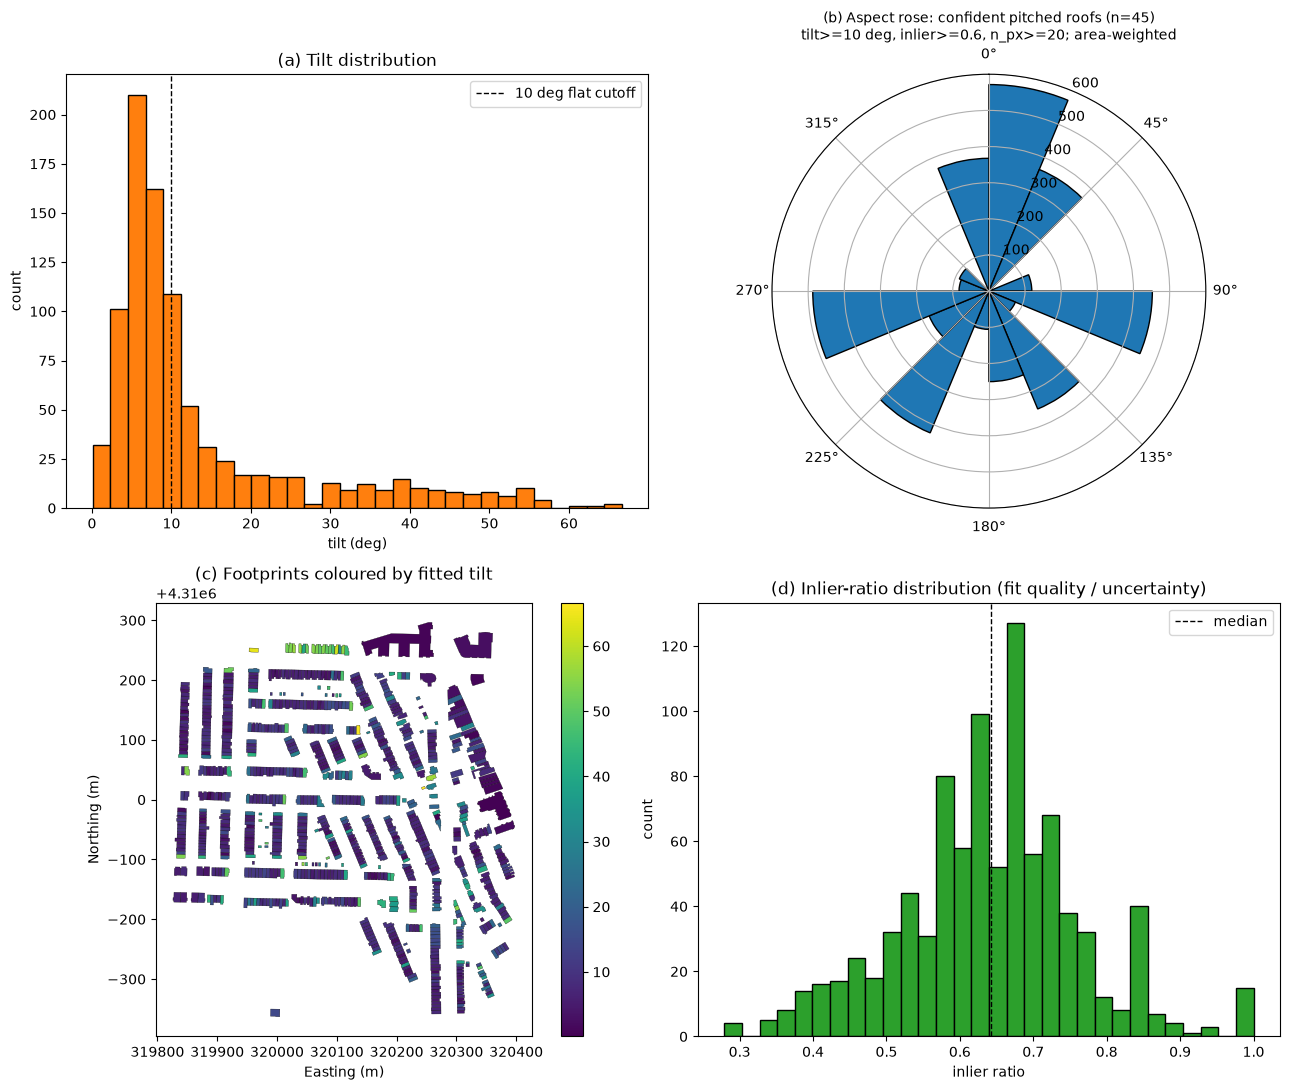

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

axes[0, 0].hist(valid_roofs["tilt_deg"], bins=30, color="tab:orange", edgecolor="black")
axes[0, 0].axvline(FLAT_THRESHOLD_DEG, color="black", ls="--", lw=1,
                    label=f"{FLAT_THRESHOLD_DEG:.0f} deg flat cutoff")
axes[0, 0].set_title("(a) Tilt distribution"); axes[0, 0].set_xlabel("tilt (deg)")
axes[0, 0].set_ylabel("count"); axes[0, 0].legend()

# (b) Aspect rose -- CONFIDENT, non-flat roofs only. Aspect is meaningless for a near-flat
# plane (a tiny residual slope can flip it 180 deg), AND for a poor fit (a low-inlier
# plane's direction is clutter-driven, not a real orientation -- see Example B). So gate on
# tilt, inlier ratio, and pixel count: every wedge is then a roof we actually believe.
ASPECT_MIN_INLIER = 0.6
ASPECT_MIN_PX = 20
pitched = valid_roofs[
    (valid_roofs["tilt_deg"] >= FLAT_THRESHOLD_DEG)
    & (valid_roofs["inlier_ratio"] >= ASPECT_MIN_INLIER)
    & (valid_roofs["n_px"] >= ASPECT_MIN_PX)
]
axes[0, 1].remove()
ax_polar = fig.add_subplot(2, 2, 2, projection="polar")
ax_polar.set_theta_zero_location("N"); ax_polar.set_theta_direction(-1)
if len(pitched):
    theta = np.radians(pitched["aspect_deg"].to_numpy())
    weights = pitched["area_m2"].to_numpy()
    bin_edges = np.linspace(0, 2 * np.pi, 17)
    hist, edges = np.histogram(theta, bins=bin_edges, weights=weights)
    ax_polar.bar(edges[:-1], hist, width=np.diff(edges), align="edge",
                 color="tab:blue", edgecolor="black")
ax_polar.set_title(
    f"(b) Aspect rose: confident pitched roofs (n={len(pitched)})\n"
    f"tilt>={FLAT_THRESHOLD_DEG:.0f} deg, inlier>={ASPECT_MIN_INLIER}, n_px>={ASPECT_MIN_PX}; "
    "area-weighted", fontsize=10)

# (c) Footprints map coloured by fitted tilt.
valid_roofs.plot(ax=axes[1, 0], column="tilt_deg", cmap="viridis", legend=True,
                  edgecolor="black", lw=0.2)
axes[1, 0].set_title("(c) Footprints coloured by fitted tilt")
axes[1, 0].set_xlabel("Easting (m)"); axes[1, 0].set_ylabel("Northing (m)")

# (d) Inlier-ratio distribution -- the uncertainty picture.
axes[1, 1].hist(valid_roofs["inlier_ratio"], bins=30, color="tab:green", edgecolor="black")
axes[1, 1].axvline(valid_roofs["inlier_ratio"].median(), color="black", ls="--", lw=1,
                    label="median")
axes[1, 1].set_title("(d) Inlier-ratio distribution (fit quality / uncertainty)")
axes[1, 1].set_xlabel("inlier ratio"); axes[1, 1].set_ylabel("count"); axes[1, 1].legend()

plt.tight_layout(); plt.show()

## Honest findings

- **Roofs here are mostly flat.** The printed median tilt is low and a large majority of roofs
  fall under the 10-degree flat cutoff (panel a). For this low-rise Glover Park slice, the
  practical takeaway is that a **flat-roof / fixed-tilt racking assumption dominates**, not steep
  pitches — a functional cousin of the block-model path, even though this is the LiDAR mode.
  Consequence: aspect is only plotted (panel b) for the *non-flat* roofs, and further
  restricted to **confident** fits (inlier >= 0.6, >= 20 px) — a poorly-fit plane's
  direction is clutter-driven, not a real orientation (Example B is exactly such a case).
- **Single-plane RANSAC is a rough fit, not a precise one.** The median inlier ratio (panel d) is
  modest, well short of 1.0 — real roofs carry HVAC clutter, parapets, and multiple facets that
  one plane cannot represent well. That's the honest state of this baseline: it gives a usable
  point estimate, but the inlier ratio (and the raw pixel count) is the uncertainty that must
  travel downstream with it — a roof with a low inlier ratio or few pixels should be treated as
  low-confidence in stage 6, not silently trusted at face value.
- **The 2 m DSM limits small roofs.** Small rowhouse-scale footprints clip to relatively few
  pixels; the `< MIN_PX` guard above flags the smallest outright, and the pixel-count numbers
  printed for the two examples make the gap between a well-sampled and a marginally-sampled roof
  concrete.

This is exactly the case for **Phase 2's ML route** (obstruction segmentation + multi-plane
fitting): a single robust plane is a reasonable Phase 1 baseline, but it is not the last word on
any individual roof's tilt/aspect (risks §14.4).

## The multi-plane gap (brief — Phase 2)

A single plane is fundamentally the wrong shape for a **gable/hip roof**: two (or more) facets
facing different directions get averaged into one compromise plane, and the inlier ratio drops to
flag exactly that. Two Phase-2-scoped fixes, not implemented here:

- **Iterative RANSAC** — fit a plane, remove its inliers, refit on what's left, repeat until the
  residual point count is too small to bother. Cheap, still classical, recovers multiple facets.
- **ML segmentation** — a learned model that separates obstructions (HVAC, chimneys) from roof
  surface *and* splits multi-facet roofs into per-facet planes before fitting. Higher fidelity,
  the plan's stated Phase 2 direction, but needs training data / a model, not just more `sklearn`.

Both are out of scope here — the point of this notebook is to establish the Phase 1 baseline and
measure honestly how far it falls short, which is exactly what the inlier-ratio distribution
above already did.

## What this established

- A **RANSAC single-plane fit**, per footprint, from footprint + DSM alone — tilt, aspect, and an
  inlier-ratio / pixel-count uncertainty proxy for every roof in the AOI.
- The **aspect sign convention** is verified against a synthetic south-facing roof (~180 deg), so
  the compass reading on real roofs (panel b) can be trusted directionally.
- **This neighbourhood's roofs are mostly flat**, and the single-plane fit is a rough, not
  precise, approximation — both facts are reported quantitatively, not asserted.

**Next:** notebook `04` — stage 5 (usable-area filter) and stage 6 (PVWatts annual yield). Tilt
and aspect from *this* notebook feed both: usable area needs tilt to exclude/derate steep or
poorly-oriented roof area, and PVWatts needs tilt + aspect (plus the shaded insolation from `02`)
to price each roof's annual kWh.